# Model Components Deep Dive

This notebook explores each component of the Rosen-Roback model in detail:

1. **Worker Utility** - How workers compare locations
2. **Housing Supply** - How rents respond to population
3. **Agglomeration** - Why big cities are productive
4. **The Equilibrium Solver** - How workers "flow" to equilibrium
5. **Parameter Sensitivity** - Which parameters matter most

**Prerequisites**:

- Read [Notebook 1: Using the Model](01_using_rosen_roback.ipynb) first
- The [Rosen-Roback blog post](https://www.henrydashwood.com/posts/rosen-roback-model) provides the theoretical foundation


In [ ]:
import sys
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")

from src.models.rosen_roback import RosenRobackModel, ThreeCityDataset, ModelParameters, CityParameters
from src.visualization import plot_equilibrium_summary, plot_supply_elasticity_effect, COLORS, create_figure

## 1. Worker Utility

### The Utility Function

Workers choose where to live based on **utility** - a measure of how well-off they are. In our model:

$$V_i = \frac{w_i}{r_i^\beta} \cdot a_i$$

where:

- $w_i$ = wage in city $i$
- $r_i$ = rent in city $i$
- $\beta$ = housing expenditure share (typically 0.33)
- $a_i$ = amenity value (quality of life)

### Why This Form?

This is a **CES (Constant Elasticity of Substitution)** utility function:

- Utility increases with wages (more income = better)
- Utility decreases with rents (raised to power $\beta$)
- The $\beta$ parameter controls how much rents hurt relative to wages

Let's explore how changes in wages and rents affect utility:


In [3]:
def utility(wage: float, rent: float, amenity: float = 1.0, beta: float = 0.33) -> float:
    """Calculate worker utility."""
    return (wage / (rent**beta)) * amenity


# Base case
base_wage = 40000
base_rent = 15000
base_utility = utility(base_wage, base_rent)

print(f"Base case: wage={base_wage:,}, rent={base_rent:,}")
print(f"Base utility: {base_utility:.2f}\n")

# Compare scenarios
scenarios = [
    ("10% wage increase", base_wage * 1.10, base_rent),
    ("10% rent increase", base_wage, base_rent * 1.10),
    ("Both +10%", base_wage * 1.10, base_rent * 1.10),
    ("Double wages", base_wage * 2, base_rent),
    ("Double rent", base_wage, base_rent * 2),
]

print(f"{'Scenario':<25} {'Wage':>10} {'Rent':>10} {'Utility':>10} {'Change':>10}")
print("-" * 70)
for name, w, r in scenarios:
    u = utility(w, r)
    change = (u / base_utility - 1) * 100
    print(f"{name:<25} {w:>10,.0f} {r:>10,.0f} {u:>10.2f} {change:>+9.1f}%")

Base case: wage=40,000, rent=15,000
Base utility: 1674.75

Scenario                        Wage       Rent    Utility     Change
----------------------------------------------------------------------
10% wage increase             44,000     15,000    1842.22     +10.0%
10% rent increase             40,000     16,500    1622.89      -3.1%
Both +10%                     44,000     16,500    1785.18      +6.6%
Double wages                  80,000     15,000    3349.50    +100.0%
Double rent                   40,000     30,000    1332.32     -20.4%


### Key Insight: Rent Changes Matter Less Than You'd Think

Because $\beta = 0.33$, a 10% rent increase only reduces utility by about 3.3%. This makes sense: housing is only 1/3 of your budget, so a 10% price increase only costs you 3.3% of income.

But rent can still dominate when cities have _very_ different rent levels:


In [13]:
# London-like: high wages, very high rents
london_wage = 50000
london_rent = 25000
london_utility = utility(london_wage, london_rent)

# Manchester-like: moderate wages, moderate rents
manchester_wage = 38000
manchester_rent = 9000
manchester_utility = utility(manchester_wage, manchester_rent)

print(f"London:     wage={london_wage:,}, rent={london_rent:,}, utility={london_utility:.2f}")
print(f"Manchester: wage={manchester_wage:,}, rent={manchester_rent:,}, utility={manchester_utility:.2f}")
print()

if manchester_utility > london_utility:
    print(f"Manchester has {(manchester_utility / london_utility - 1) * 100:.1f}% higher utility!")
    print("Despite lower wages, the much lower rents make it more attractive.")

London:     wage=50,000, rent=25,000, utility=1768.68
Manchester: wage=38,000, rent=9,000, utility=1883.14

Manchester has 6.5% higher utility!
Despite lower wages, the much lower rents make it more attractive.


### Visualizing the Utility Surface


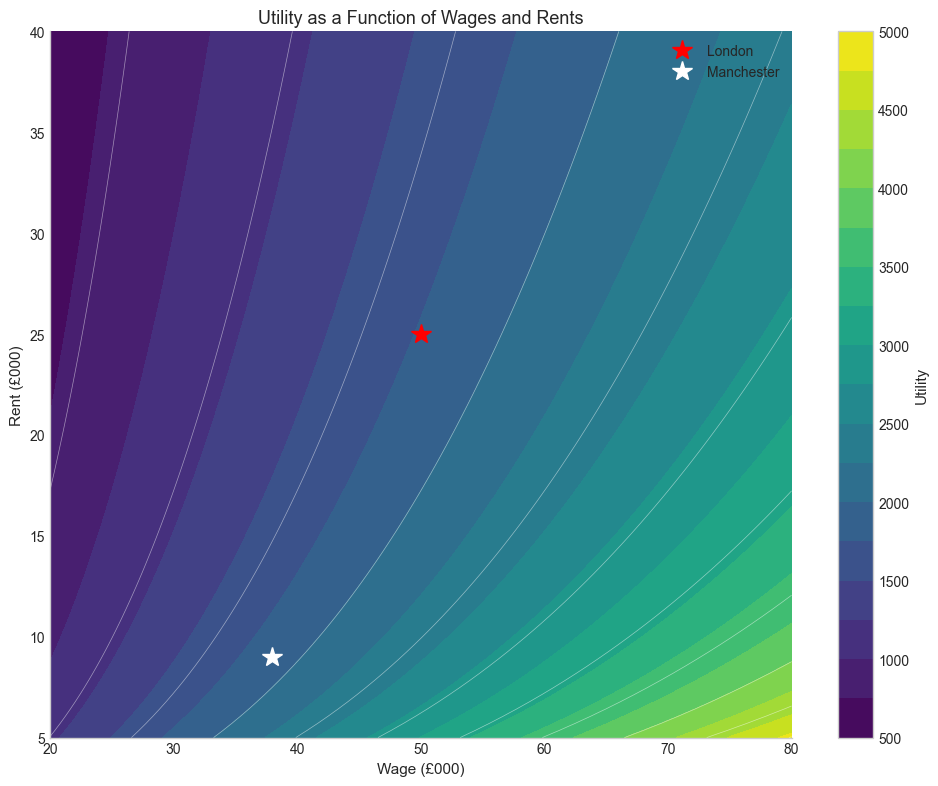

Points on the same contour line (iso-utility curve) give equal utility.
Moving northeast (higher wages AND rents) can leave utility unchanged.


In [5]:
# Create contour plot of utility
wages = np.linspace(20000, 80000, 100)
rents = np.linspace(5000, 40000, 100)
W, R = np.meshgrid(wages, rents)
U = utility(W, R)

fig, ax = create_figure(figsize=(10, 8))

# Contour plot
contour = ax.contourf(W / 1000, R / 1000, U, levels=20, cmap="viridis")
plt.colorbar(contour, ax=ax, label="Utility")

# Add iso-utility lines
ax.contour(W / 1000, R / 1000, U, levels=10, colors="white", linewidths=0.5, alpha=0.5)

# Mark some example cities
ax.plot(london_wage / 1000, london_rent / 1000, "r*", markersize=15, label="London")
ax.plot(manchester_wage / 1000, manchester_rent / 1000, "w*", markersize=15, label="Manchester")

ax.set_xlabel("Wage (£000)")
ax.set_ylabel("Rent (£000)")
ax.set_title("Utility as a Function of Wages and Rents")
ax.legend()

plt.tight_layout()
plt.show()

print("Points on the same contour line (iso-utility curve) give equal utility.")
print("Moving northeast (higher wages AND rents) can leave utility unchanged.")

## 2. Housing Supply

### The Supply Function

Housing supply responds to rents:

$$H_i = S_i \cdot r_i^\gamma$$

where:

- $H_i$ = housing units supplied
- $S_i$ = supply shifter (land, regulations)
- $r_i$ = rent
- $\gamma$ = **supply elasticity**

### Housing Market Equilibrium

Each worker needs one housing unit, so demand = population. In equilibrium:

$$H_i = L_i \implies r_i = \left(\frac{L_i}{S_i}\right)^{1/\gamma}$$

### Why Elasticity Matters

The elasticity $\gamma$ determines how much rents respond to population:

- **High $\gamma$ (elastic)**: Rents barely rise when population grows
- **Low $\gamma$ (inelastic)**: Rents spike when population grows


In [6]:
def equilibrium_rent(population: float, supply_shifter: float, elasticity: float) -> float:
    """Calculate equilibrium rent given population."""
    return (population / supply_shifter) ** (1 / elasticity)


# Compare cities with different elasticities
supply_shifter = 1_000_000
pop_increase = 1.2  # 20% population increase

print("Effect of 20% population increase on rents:")
print()
print(f"{'City Type':<25} {'Elasticity':>12} {'Rent Before':>12} {'Rent After':>12} {'% Change':>12}")
print("-" * 75)

for name, gamma in [
    ("San Francisco-like", 0.66),
    ("Average US city", 1.5),
    ("Houston-like", 2.5),
]:
    rent_before = equilibrium_rent(1_000_000, supply_shifter, gamma)
    rent_after = equilibrium_rent(1_000_000 * pop_increase, supply_shifter, gamma)
    change = (rent_after / rent_before - 1) * 100
    print(f"{name:<25} {gamma:>12.2f} {rent_before:>12.2f} {rent_after:>12.2f} {change:>+11.1f}%")

Effect of 20% population increase on rents:

City Type                   Elasticity  Rent Before   Rent After     % Change
---------------------------------------------------------------------------
San Francisco-like                0.66         1.00         1.32       +31.8%
Average US city                   1.50         1.00         1.13       +12.9%
Houston-like                      2.50         1.00         1.08        +7.6%


### Visualizing Supply Elasticity


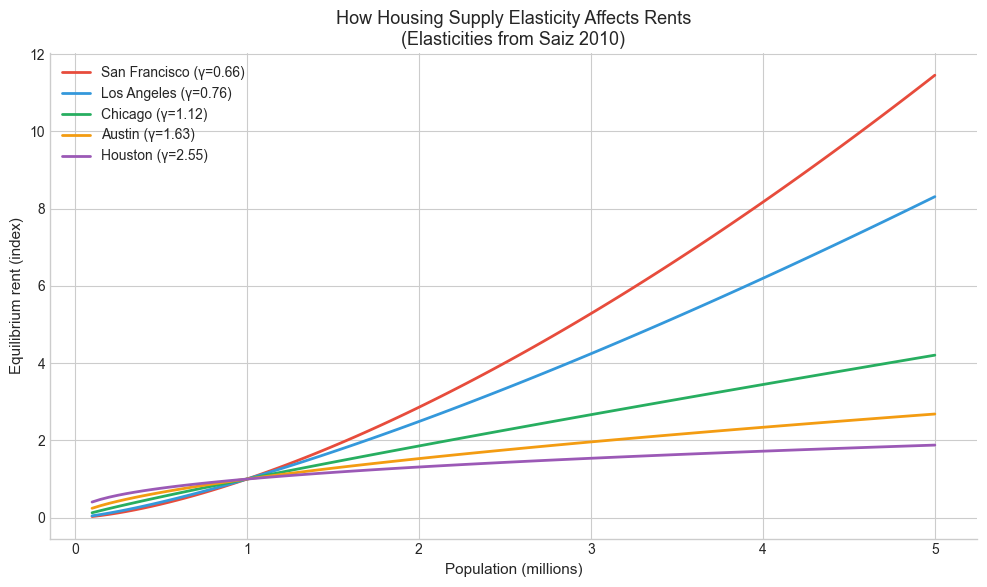

In [7]:
populations = np.linspace(100_000, 5_000_000, 100)

# Empirical elasticities from Saiz (2010)
fig = plot_supply_elasticity_effect(
    populations,
    elasticities=[0.66, 0.76, 1.12, 1.63, 2.55],
    labels=[
        "San Francisco (γ=0.66)",
        "Los Angeles (γ=0.76)",
        "Chicago (γ=1.12)",
        "Austin (γ=1.63)",
        "Houston (γ=2.55)",
    ],
    title="How Housing Supply Elasticity Affects Rents\n(Elasticities from Saiz 2010)",
)
plt.show()

### What Determines Elasticity?

According to [Saiz (2010)](https://academic.oup.com/qje/article/125/3/1253/1903664), housing supply elasticity depends on:

1. **Geography**: Coastal cities, mountains, and water bodies limit land
2. **Regulation**: Zoning, height limits, environmental reviews
3. **Construction costs**: Land prices, labor costs, materials

The most productive US cities (NYC, SF, Boston) tend to have the _lowest_ elasticities. This is the core tension the model captures.


## 3. Agglomeration

### Why Are Big Cities More Productive?

Cities exhibit **agglomeration economies**: productivity increases with size. The model captures this as:

$$A_i = \bar{A}_i \cdot L_i^\eta$$

where:

- $A_i$ = total factor productivity
- $\bar{A}_i$ = base productivity (technology, institutions)
- $L_i$ = population/employment
- $\eta$ = **agglomeration elasticity**

### Sources of Agglomeration

Three classic mechanisms (from Marshall, 1890):

1. **Labour market pooling**: Easier to find the right worker/job
2. **Input sharing**: Access to specialized suppliers
3. **Knowledge spillovers**: Learning from others nearby

### Empirical Estimates

Studies typically find $\eta \approx 0.02-0.08$:

- Doubling city size increases productivity by 2-8%
- Hsieh-Moretti (2019) and Cooped Up use $\eta = 0.25$ (controversial!)


In [8]:
def productivity(population: float, base_tfp: float, eta: float) -> float:
    """Calculate TFP with agglomeration."""
    return base_tfp * (population**eta)


# Compare different agglomeration elasticities
base_pop = 1_000_000
big_city_pop = 10_000_000  # 10x larger

print("Effect of 10x city size on productivity:")
print()
print(f"{'Agglomeration (η)':<20} {'TFP (1M pop)':<15} {'TFP (10M pop)':<15} {'% Increase':<15}")
print("-" * 65)

for eta in [0.02, 0.04, 0.06, 0.08, 0.25]:
    tfp_small = productivity(base_pop, 100, eta)
    tfp_large = productivity(big_city_pop, 100, eta)
    increase = (tfp_large / tfp_small - 1) * 100
    print(f"{eta:<20.2f} {tfp_small:<15.1f} {tfp_large:<15.1f} {increase:<14.1f}%")

Effect of 10x city size on productivity:

Agglomeration (η)    TFP (1M pop)    TFP (10M pop)   % Increase     
-----------------------------------------------------------------
0.02                 131.8           138.0           4.7           %
0.04                 173.8           190.5           9.6           %
0.06                 229.1           263.0           14.8          %
0.08                 302.0           363.1           20.2          %
0.25                 3162.3          5623.4          77.8          %


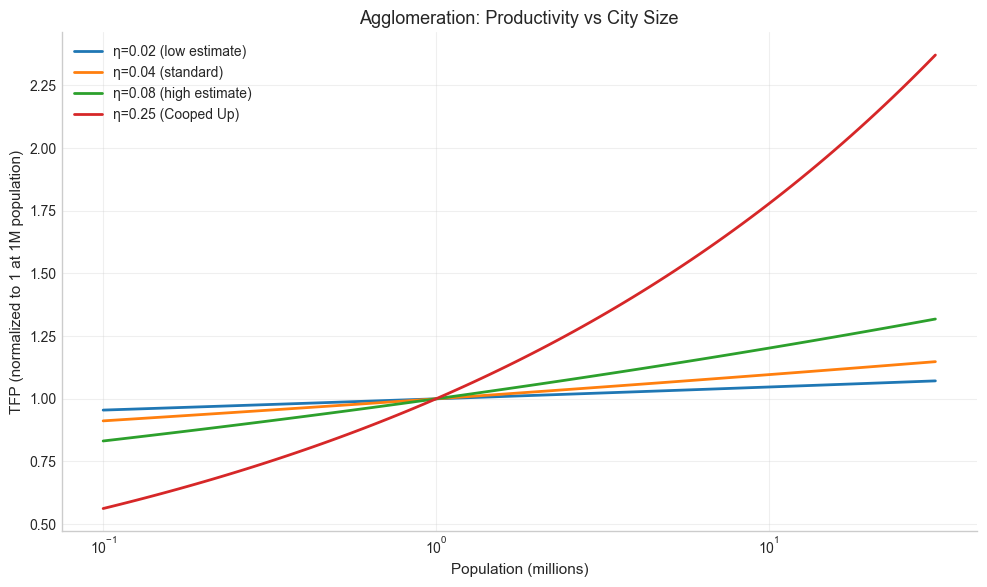

Note: The Cooped Up η=0.25 implies London (10M) is 78% more productive than
a 1M city. Standard estimates (η=0.04) imply only 10% higher productivity.


In [9]:
# Visualize agglomeration effects
populations = np.logspace(5, 7.5, 100)  # 100K to 30M

fig, ax = create_figure(figsize=(10, 6))

for eta, label in [
    (0.02, "η=0.02 (low estimate)"),
    (0.04, "η=0.04 (standard)"),
    (0.08, "η=0.08 (high estimate)"),
    (0.25, "η=0.25 (Cooped Up)"),
]:
    tfp = productivity(populations, 100, eta)
    # Normalize to base at 1M population
    tfp_normalized = tfp / productivity(1_000_000, 100, eta)
    ax.plot(populations / 1e6, tfp_normalized, label=label, linewidth=2)

ax.set_xscale("log")
ax.set_xlabel("Population (millions)")
ax.set_ylabel("TFP (normalized to 1 at 1M population)")
ax.set_title("Agglomeration: Productivity vs City Size")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: The Cooped Up η=0.25 implies London (10M) is 78% more productive than")
print("a 1M city. Standard estimates (η=0.04) imply only 10% higher productivity.")

## 4. The Equilibrium Solver

### The Equilibrium Concept

In equilibrium, workers are **approximately indifferent** between cities. If one city offered strictly higher utility, workers would move there.

The model uses a probabilistic formulation:

$$\text{share}_i \propto V_i^\theta$$

where $\theta$ is the **mobility parameter**. Higher $\theta$ means workers respond more sharply to utility differences.

### The Algorithm

1. Start with equal population distribution
2. Calculate wages and rents from population
3. Calculate utility in each city
4. Reallocate workers toward high-utility cities
5. Repeat until utilities converge

### Watching the Solver Work


In [10]:
from src.models.rosen_roback.equilibrium import EquilibriumSolver

# Create a simple three-city setup
params = ModelParameters()
cities = [
    CityParameters("High Prod", base_tfp=120, supply_elasticity=1.5),
    CityParameters("Medium", base_tfp=100, supply_elasticity=2.0),
    CityParameters("Low Prod", base_tfp=80, supply_elasticity=3.0),
]

solver = EquilibriumSolver(params, cities)

# Solve with verbose output
print("Solving for equilibrium...")
print()
result = solver.solve(total_population=3_000_000, verbose=True)
print()
print(f"Converged in {result.iterations} iterations")
print()
print(result.summary())

Solving for equilibrium...

Iteration 0: share change = 9.70e-02, utility spread = 42.53%

Converged in 64 iterations

Spatial Equilibrium Results
City                        Population       Wage       Rent    Utility
----------------------------------------------------------------------
High Prod                      713,304       1.20      79.83     0.2817
Medium                         973,846       0.90      31.21     0.2907
Low Prod                     1,312,850       0.66      10.95     0.2995
----------------------------------------------------------------------
Total GDP: 3,999,865
Utility spread: 6.3% (smaller = closer to classic R-R equilibrium)
Converged: True (64 iterations)


### How Mobility (θ) Affects Equilibrium

Higher θ means workers are more responsive to utility differences, leading to tighter convergence:


In [11]:
print("Effect of mobility parameter θ on utility equalization:")
print()
print(f"{'θ':<10} {'HP Utility':<15} {'Med Utility':<15} {'LP Utility':<15} {'Max Spread':<15}")
print("-" * 70)

for theta in [1.0, 2.0, 3.0, 5.0, 10.0]:
    test_params = ModelParameters(theta=theta)
    test_solver = EquilibriumSolver(test_params, cities)
    result = test_solver.solve(total_population=3_000_000)

    utilities = np.array(result.utilities)
    spread = (utilities.max() / utilities.min() - 1) * 100

    print(f"{theta:<10.1f} {utilities[0]:<15.4f} {utilities[1]:<15.4f} {utilities[2]:<15.4f} {spread:<14.2f}%")

print()
print("Higher θ → utilities converge more closely.")
print("In the limit (θ→∞), utilities would be perfectly equal.")

Effect of mobility parameter θ on utility equalization:

θ          HP Utility      Med Utility     LP Utility      Max Spread     
----------------------------------------------------------------------
1.0        0.2521          0.2868          0.3203          27.08         %
2.0        0.2613          0.2875          0.3131          19.83         %
3.0        0.2671          0.2882          0.3089          15.64         %
5.0        0.2741          0.2893          0.3042          10.98         %
10.0       0.2817          0.2907          0.2995          6.29          %

Higher θ → utilities converge more closely.
In the limit (θ→∞), utilities would be perfectly equal.


## 5. Parameter Sensitivity

Let's systematically explore how each parameter affects the model's GDP predictions.

### Sensitivity to Agglomeration (η)

This is the most important parameter:


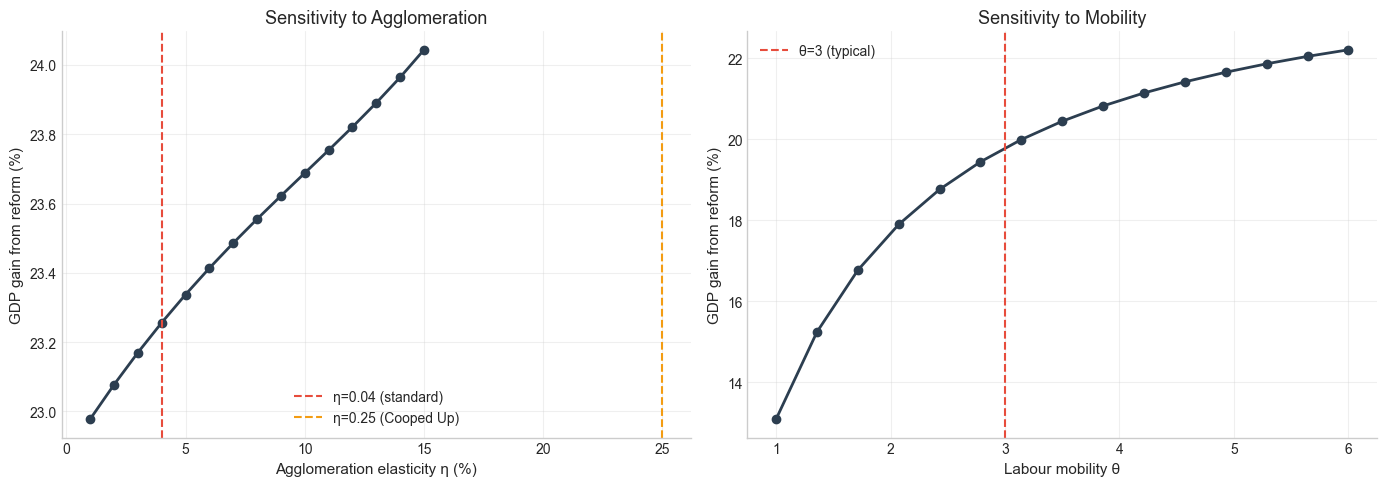

In [12]:
def calculate_gdp_gain(params: ModelParameters, baseline_elasticity: float, reform_elasticity: float) -> float:
    """Calculate GDP gain from changing HP city elasticity."""
    model = RosenRobackModel(params)

    baseline = ThreeCityDataset(high_elasticity=baseline_elasticity)
    reform = ThreeCityDataset(high_elasticity=reform_elasticity)

    result_baseline = model.solve(baseline)
    result_reform = model.solve(reform)

    return (result_reform.total_gdp / result_baseline.total_gdp - 1) * 100


# Vary eta
etas = np.linspace(0.01, 0.15, 15)
gdp_gains_eta = [calculate_gdp_gain(ModelParameters(eta=e), 0.5, 3.0) for e in etas]

fig, axes = create_figure(1, 2, figsize=(14, 5))

axes[0].plot(etas * 100, gdp_gains_eta, "o-", linewidth=2, markersize=6, color=COLORS["primary"])
axes[0].axvline(x=4, color=COLORS["secondary"], linestyle="--", label="η=0.04 (standard)")
axes[0].axvline(x=25, color=COLORS["warning"], linestyle="--", label="η=0.25 (Cooped Up)")
axes[0].set_xlabel("Agglomeration elasticity η (%)")
axes[0].set_ylabel("GDP gain from reform (%)")
axes[0].set_title("Sensitivity to Agglomeration")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Vary theta
thetas = np.linspace(1.0, 6.0, 15)
gdp_gains_theta = [calculate_gdp_gain(ModelParameters(theta=t), 0.5, 3.0) for t in thetas]

axes[1].plot(thetas, gdp_gains_theta, "o-", linewidth=2, markersize=6, color=COLORS["primary"])
axes[1].axvline(x=3.0, color=COLORS["secondary"], linestyle="--", label="θ=3 (typical)")
axes[1].set_xlabel("Labour mobility θ")
axes[1].set_ylabel("GDP gain from reform (%)")
axes[1].set_title("Sensitivity to Mobility")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Key Findings

1. **Agglomeration (η) is crucial**: The GDP gain from housing reform scales roughly linearly with η. This is why the choice of η is so contested.

2. **Mobility (θ) matters too**: Higher mobility means workers respond more to utility differences, amplifying the reallocation effect.

3. **The parameters interact**: High η + high θ = very large GDP effects; low η + low θ = modest effects.

### Why Parameter Choices Are Controversial

The literature disagrees on the right value of η:

| Study                | η         | GDP Effect of Housing Reform |
| -------------------- | --------- | ---------------------------- |
| Standard estimates   | 0.02-0.08 | 1-3%                         |
| Hsieh-Moretti (2019) | 0.25      | 3-9%                         |
| Cooped Up (2024)     | 0.25      | 5-10%                        |

The Cooped Up paper's large effects depend heavily on the high η assumption.


## Summary

You've explored the four key components of the Rosen-Roback model:

1. **Worker Utility**: $V = w/r^\beta \cdot a$ captures the wage-rent-amenity tradeoff

2. **Housing Supply**: $H = S \cdot r^\gamma$ - elasticity (γ) determines rent response to population

3. **Agglomeration**: $A = \bar{A} \cdot L^\eta$ - bigger cities are more productive

4. **Equilibrium**: Workers flow until utilities approximately equalize

### Key Parameters

| Parameter         | Symbol | Role                              | Typical Range       |
| ----------------- | ------ | --------------------------------- | ------------------- |
| Housing share     | β      | How much rents hurt utility       | 0.30-0.35           |
| Supply elasticity | γ      | How rents respond to population   | 0.5-3.0             |
| Agglomeration     | η      | Productivity boost from city size | 0.02-0.08 (or 0.25) |
| Mobility          | θ      | How responsive workers are        | 2-4                 |

## Next Steps

- [Notebook 3: Building from First Principles](03_rosen_roback_from_scratch.ipynb) - Full mathematical derivation
- [Cooped Up Replication](04_cooped_up_replication.ipynb) - Apply to real UK data
